In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import re, unicodedata
from collections import Counter


In [ ]:
#路径配置

IN_REF = Path("/content/chengyu_merged_unique.txt")
IN_CORPUS = Path("/content/ch2_all_data_2015_2025_tok_thulac.csv")
OUT_DIR = Path("/content/identification")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ref:", IN_REF)
print("corpus:", IN_CORPUS)
print("out:", OUT_DIR)


ref: /content/chengyu_merged_unique.txt
corpus: /content/ch2_all_data_2015_2025_tok_thulac.csv
out: /content/identification


In [ ]:
#读取成语表（ref_set）/只保留：去空白、NFKC 规范化、长度=4 的条目（成语主要是四字）。

def normalize(s: str) -> str:
    s = unicodedata.normalize("NFKC", str(s))
    return s.strip()

ref_set = set()
with IN_REF.open("r", encoding="utf-8") as f:
    for line in f:
        t = normalize(line)
        if t and len(t) == 4:
            ref_set.add(t)

print("成语参考表（4字）条目数:", len(ref_set))


成语参考表（4字）条目数: 29743


In [ ]:
#Step 3 — 读取语料 CSV，并取出 content / year

try:
    df = pd.read_csv(IN_CORPUS, encoding="utf-8", on_bad_lines='skip', engine='python')
except UnicodeDecodeError:
    print("UTF-8 decoding failed, trying GBK encoding...")
    try:
        df = pd.read_csv(IN_CORPUS, encoding="gb18030", on_bad_lines='skip', engine='python', encoding_errors='ignore')
    except UnicodeDecodeError:
        print("GB18030 decoding failed, trying latin-1 encoding...")
        df = pd.read_csv(IN_CORPUS, encoding="latin-1", on_bad_lines='skip', engine='python', encoding_errors='ignore')

if "content" not in df.columns:
    raise ValueError("CSV 缺少 'content' 列")

df["content"] = df["content"].fillna("").astype(str).map(normalize)

# 年份（如果 date 列不存在，会得到 NaN）
if "date" in df.columns:
    df["date_parsed"] = pd.to_datetime(df["date"], errors="coerce")
    df["year"] = df["date_parsed"].dt.year
else:
    df["year"] = np.nan

print("语料行数:", len(df))
df.head(2)

UTF-8 decoding failed, trying GBK encoding...
语料行数: 489


,author,title,date,content,date_parsed,year
0,(鐜嬭繛棣欍侀珮闆),NaN,NaN,浜烘皯缃 鍖椾含 9鏈 28鏃 鐢 锛 璁拌 鐜 杩 棣 锛 鍦 浠婃棩 涓捐 鐨 浜ら ...,NaT,NaN
1,(鐜嬭繛棣欍侀珮闆),NaN,NaN,浜烘皯缃 鍖椾含 9鏈 28鏃 鐢 锛 璁拌 鐜 杩 棣 锛 鎹 涓浗 鍥 瀹 閾佽矾 闆...,NaT,NaN


In [ ]:
#Step 4 — 字符级处理函数（把 content 转成“字符序列 + 句子切分 + 4字滑窗”）

#注意： content 是 THULAC token 后带空格的文本。我们这里用字符级扫描，只保留汉字 + 句末标点用于断句。


# 句子分隔符
SENT_SEP = set("。！？!?；;：:")

# 只认汉字（基础区）
zh_char_re = re.compile(r"[\u4e00-\u9fff]")

def to_char_list(text: str):
    """把文本变成字符序列：保留 汉字 + 句末分隔符"""
    chars = []
    for ch in text:
        if ch in SENT_SEP:
            chars.append(ch)
        elif zh_char_re.match(ch):
            chars.append(ch)
    return chars

def split_char_sent(chars):
    """按 SENT_SEP 切分句子"""
    sents, cur = [], []
    for ch in chars:
        cur.append(ch)
        if ch in SENT_SEP:
            sents.append(cur)
            cur = []
    if cur:
        sents.append(cur)
    return sents

def char_windows_in_sentence(sent_chars, n=4):
    """句内滑窗：只在汉字序列上做窗口，不跨句"""
    clean = [c for c in sent_chars if c not in SENT_SEP]
    for i in range(len(clean) - n + 1):
        yield "".join(clean[i:i+n])


In [ ]:
#Step 5 — 阶段 A：统计“不在成语表里的 4 字串”（freq / docfreq / first_year）

freq = Counter()      # 总频次
docfreq = Counter()   # 文档频次（每篇文章出现算1）
first_year = {}       # 首次出现年份（如果 year 有值）

for row in df.itertuples(index=False):
    content = getattr(row, "content")
    year = getattr(row, "year")

    chars = to_char_list(content)
    sents = split_char_sent(chars)

    seen_doc = set()  # 本文档出现过的候选（用于 docfreq）
    for sent in sents:
        for cand in char_windows_in_sentence(sent, 4):
            if cand not in ref_set:
                freq[cand] += 1
                seen_doc.add(cand)

    for w in seen_doc:
        docfreq[w] += 1
        if pd.notna(year) and w not in first_year:
            first_year[w] = int(year)

print("候选新四字串数量:", len(freq))


候选新四字串数量: 358061


In [ ]:
#Step 6 — 导出结果表（新成语候选）
rows = []
for term, f in freq.items():
    rows.append({
        "term": term,
        "freq": int(f),
        "doc_freq": int(docfreq[term]),
        "first_year": first_year.get(term, np.nan),
        "in_reference": False
    })

df_new = pd.DataFrame(rows).sort_values(
    ["freq", "doc_freq"], ascending=[False, False]
).reset_index(drop=True)

out_path = OUT_DIR / "A_new_4char_candidates.csv"
df_new.to_csv(out_path, index=False, encoding="utf-8-sig")

print("保存:", out_path)
df_new.head(20)


保存: /content/identification/A_new_4char_candidates.csv


,term,freq,doc_freq,first_year,in_reference
0,锟斤拷锟,702,17,NaN,False
1,涔犺繎骞,686,120,2022.0,False
2,拷锟斤拷,549,17,NaN,False
3,斤拷锟斤,522,17,NaN,False
4,鍚堜綔缁,421,19,2022.0,False
5,堜綔缁勭,420,19,2022.0,False
6,綔缁勭粐,420,19,2022.0,False
7,涓婃捣鍚,416,20,2022.0,False
8,婃捣鍚堜,416,20,2022.0,False
9,捣鍚堜綔,416,20,2022.0,False


#语义检测

In [ ]:
!pip install python-Levenshtein



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 10.5 MB/s eta 0:00:00


In [ ]:
! pip install tqdm

In [ ]:
from tqdm import tqdm
import Levenshtein

variants = []
ref_list = list(ref_set)

for cand in tqdm(df_new["term"], desc="Processing candidates"):
    for ref in ref_list:
        if Levenshtein.distance(cand, ref) == 1:
            variants.append({
                "variant": cand,
                "original": ref,
                "type": "edit_distance_1"
            })


Processing candidates: 100%|██████████| 358061/358061 [2:12:16<00:00, 45.12it/s]


In [ ]:
#3保存结果
df_var = pd.DataFrame(variants).drop_duplicates()

out_path = OUT_DIR / "B1_idiom_variants_editdistance.csv"
df_var.to_csv(out_path, index=False, encoding="utf-8-sig")

print("检测到变体数量:", len(df_var))
print("保存:", out_path)
df_var.head(10)


检测到变体数量: 0
保存: /content/identification/B1_idiom_variants_editdistance.csv


""


In [ ]:
#Step 2：拼音同音变体检测（默默无闻 → 默默无蚊）

#安装拼音库

!pip install pypinyin


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 840.2/840.2 kB 9.1 MB/s eta 0:00:00


In [ ]:
#. 拼音函数

from pypinyin import lazy_pinyin

def pinyin_str(s):
    return "".join(lazy_pinyin(s))


#以下在上面大数据没有用的情况下使用

In [ ]:
variants = []
ref_list = list(ref_set)

#以上在上面大数据没有用的情况下使用

In [ ]:
#3. 同音变体检测


from tqdm import tqdm
from pypinyin import lazy_pinyin

variants_pinyin = []

for cand in tqdm(df_new["term"], desc="Processing candidates"):
    for ref in ref_list:
        if len(cand) != 4 or len(ref) != 4:
            continue

        diff_pos = [i for i in range(4) if cand[i] != ref[i]]
        if len(diff_pos) == 1:
            i = diff_pos[0]
            if lazy_pinyin(cand[i]) == lazy_pinyin(ref[i]):
                variants_pinyin.append({
                    "variant": cand,
                    "original": ref,
                    "type": "homophone_substitution",
                    "pos": i
                })




Processing candidates: 100%|██████████| 358061/358061 [4:16:07<00:00, 23.30it/s]


In [ ]:
#4. 保存
df_var_py = pd.DataFrame(variants_pinyin).drop_duplicates()

out_path2 = OUT_DIR / "B2_idiom_variants_homophone.csv"
df_var_py.to_csv(out_path2, index=False, encoding="utf-8-sig")

print("同音变体数量:", len(df_var_py))
print("保存:", out_path2)
df_var_py.head(10)


In [ ]:
#Step 3（可选）：合并结果

df_all = pd.concat([df_var, df_var_py], ignore_index=True).drop_duplicates()

out_all = OUT_DIR / "B_all_idiom_variants.csv"
df_all.to_csv(out_all, index=False, encoding="utf-8-sig")

print("全部变体数:", len(df_all))
print("保存:", out_all)


现在将得到 3 个文件：
文件	含义
A_new_4char_candidates.csv	新4字串
B1_idiom_variants_editdistance.csv	编辑距离变体
B2_idiom_variants_homophone.csv	同音替换变体
B_all_idiom_variants.csv	合并结果

#加入时间维度（2015–2025 语义演化）

In [ ]:
#第一阶段：时间分布（最稳妥，必做）
#Step 1 读取语料 + 变体表

import pandas as pd
from pathlib import Path

CORPUS = "/content/ch2_all_data_2015_2025_tok_thulac.csv"
VARIANTS = "/content/identification/B_all_idiom_variants.csv"

df = pd.read_csv(CORPUS)
df["date_parsed"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date_parsed"].dt.year
df["content"] = df["content"].fillna("").astype(str)

df_var = pd.read_csv(VARIANTS)
df_var.head()


In [ ]:
#Step 2 建立 “原成语 → 所有变体” 映射

from collections import defaultdict

variant_map = defaultdict(set)

for _, r in df_var.iterrows():
    variant_map[r["original"]].add(r["variant"])


In [ ]:
#Step 3 统计每年出现频率
from collections import Counter, defaultdict

year_freq = defaultdict(lambda: Counter())

for _, row in df.iterrows():
    y = row["year"]
    if pd.isna(y):
        continue
    text = row["content"]

    for orig, vars_ in variant_map.items():
        if orig in text:
            year_freq[orig][y] += 1
        for v in vars_:
            if v in text:
                year_freq[orig][y] += 1


In [ ]:
#Step 4 转成表格

rows = []
for orig, counter in year_freq.items():
    for y, f in counter.items():
        rows.append({
            "idiom": orig,
            "year": y,
            "freq": f
        })

df_time = pd.DataFrame(rows).sort_values(["idiom","year"])
out_time = Path("/content/identification/C_idiom_time_series.csv")
df_time.to_csv(out_time, index=False, encoding="utf-8-sig")

print("保存:", out_time)
df_time.head()


In [ ]:
#Step 5 可视化（快速判断演化）

import matplotlib.pyplot as plt

def plot_idiom(idiom):
    sub = df_time[df_time["idiom"]==idiom]
    plt.figure(figsize=(8,4))
    plt.plot(sub["year"], sub["freq"], marker="o")
    plt.title(idiom)
    plt.xlabel("Year")
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

plot_idiom("默默无闻")


In [ ]:
#第二阶段：语境变化（发现新义项）
#Step 6 抽取每个时期的语境句

def extract_context(idiom, years=(2015,2020,2025), window=20):
    contexts = defaultdict(list)
    for _, row in df.iterrows():
        y = row["year"]
        if y not in years:
            continue
        txt = row["content"]
        if idiom in txt:
            idx = txt.find(idiom)
            ctx = txt[max(0,idx-window): idx+len(idiom)+window]
            contexts[y].append(ctx)
    return contexts

contexts = extract_context("默默无闻")
for y, lst in contexts.items():
    print(y, lst[:3])


第三阶段（进阶）：语义向量演化（polysemy detection）

如果你想做真正的“新义项检测”：

方法
方法	工具
句向量	sentence-transformers
时间切片	每年一个 embedding
聚类	KMeans / HDBSCAN
指标	cosine drift / cluster emergence

In [ ]:
#示例：句向量漂移

!pip install sentence-transformers


In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

def mean_embedding(idiom, year):
    sents = []
    for _, row in df.iterrows():
        if row["year"]==year and idiom in row["content"]:
            sents.append(row["content"])
    if not sents:
        return None
    emb = model.encode(sents, show_progress_bar=False)
    return emb.mean(axis=0)

e2015 = mean_embedding("默默无闻", 2015)
e2025 = mean_embedding("默默无闻", 2025)

from numpy.linalg import norm
cosine = np.dot(e2015,e2025)/(norm(e2015)*norm(e2025))
print("cosine similarity:", cosine)


cos 接近 1 → 语义稳定
cos < 0.75 → 强烈语义漂移
cos < 0.6 → 新义项高度可能

## 新义项检测polysemy emergence

> Ajouter une citation


方法概览（你将得到什么）

对每个成语：

提取所有出现语境句

按年份分组

用 BERT 生成句向量

聚类（自动发现不同义项）

对比早期 vs 晚期义项分布

自动标记“新义项出现”



In [ ]:
#Step 0 — 安装依赖

!pip install sentence-transformers hdbscan scikit-learn tqdm


In [ ]:
#Step 1 — 读取语料 & 成语列表

import pandas as pd
import numpy as np
from pathlib import Path

CORPUS = "/content/ch2_all_data_2015_2025_tok_thulac.csv"
IDIOMS = "/content/identification/B_all_idiom_variants.csv"

df = pd.read_csv(CORPUS)
df["date_parsed"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date_parsed"].dt.year
df["content"] = df["content"].fillna("").astype(str)

df_id = pd.read_csv(IDIOMS)

idioms = sorted(set(df_id["original"]))
print("成语数量:", len(idioms))


In [ ]:
#Step 2 — 抽取成语语境句

def extract_sentences(idiom, window=30):
    sents = []
    years = []
    for _, row in df.iterrows():
        txt = row["content"]
        if idiom in txt:
            idx = txt.find(idiom)
            ctx = txt[max(0,idx-window): idx+len(idiom)+window]
            sents.append(ctx)
            years.append(row["year"])
    return sents, years


In [ ]:
#Step 3 — 初始化中文句向量模型

from sentence_transformers import SentenceTransformer

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")


In [ ]:
#Step 4 — 聚类函数（发现义项）

import hdbscan

def cluster_embeddings(embeddings):
    clusterer = hdbscan.HDBSCAN(min_cluster_size=5, metric='euclidean')
    labels = clusterer.fit_predict(embeddings)
    return labels


In [ ]:
#Step 5 — 新义项检测核心函数

from collections import Counter, defaultdict

def detect_polysemy(idiom):
    sents, years = extract_sentences(idiom)
    if len(sents) < 20:
        return None

    embeddings = model.encode(sents, show_progress_bar=False)
    labels = cluster_embeddings(embeddings)

    data = pd.DataFrame({
        "sentence": sents,
        "year": years,
        "cluster": labels
    })

    # 只保留有效簇
    data = data[data["cluster"] >= 0]

    if data["cluster"].nunique() < 2:
        return None

    # 年份分布
    cluster_year = defaultdict(lambda: Counter())

    for _, r in data.iterrows():
        cluster_year[r["cluster"]][r["year"]] += 1

    clusters = list(cluster_year.keys())

    early_years = range(2015, 2019)
    late_years  = range(2022, 2026)

    emergence = []

    for c in clusters:
        early_freq = sum(cluster_year[c][y] for y in early_years)
        late_freq  = sum(cluster_year[c][y] for y in late_years)

        if early_freq <= 2 and late_freq >= 10:
            emergence.append(c)

    return {
        "idiom": idiom,
        "clusters": data,
        "emerging_clusters": emergence
    }


In [ ]:
#Step 6 — 批量运行

results = []

for idiom in idioms:
    r = detect_polysemy(idiom)
    if r and len(r["emerging_clusters"])>0:
        results.append(r)

print("检测到新义项成语数:", len(results))


In [ ]:
#Step 7 — 导出结果表


rows = []

for r in results:
    for c in r["emerging_clusters"]:
        rows.append({
            "idiom": r["idiom"],
            "cluster_id": c
        })

df_poly = pd.DataFrame(rows)

OUT = Path("/content/identification/C_polysemy_emergence.csv")
df_poly.to_csv(OUT, index=False, encoding="utf-8-sig")

print("保存:", OUT)
df_poly.head()


In [ ]:
#Step 8 — 导出新义项示例语境（人工验证）

examples = []

for r in results:
    dfc = r["clusters"]
    for c in r["emerging_clusters"]:
        sub = dfc[dfc["cluster"]==c].sort_values("year").head(5)
        for _, row in sub.iterrows():
            examples.append({
                "idiom": r["idiom"],
                "cluster": c,
                "year": row["year"],
                "sentence": row["sentence"]
            })

df_examples = pd.DataFrame(examples)

OUT2 = Path("/content/identification/C_polysemy_examples.csv")
df_examples.to_csv(OUT2, index=False, encoding="utf-8-sig")

print("示例保存:", OUT2)



#频率 + 时间曲线看新变体是否近年爆发[texte du lien](https://)

一、输入假设

你已经有：

语料（已分词）：

/content/ch2_all_data_2015_2025_tok_thulac.csv


成语变体表（例如）：

/content/identification/B_all_idiom_variants.csv


字段至少包含：

original	variant
默默无闻	默默无蚊

In [ ]:
#Step 0 — 读取数据
import pandas as pd
from collections import defaultdict, Counter
import numpy as np

CORPUS = "/content/ch2_all_data_2015_2025_tok_thulac.csv"
VARIANTS = "/content/identification/B_all_idiom_variants.csv"

df = pd.read_csv(CORPUS)
df["date_parsed"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date_parsed"].dt.year
df["content"] = df["content"].fillna("").astype(str)

df_var = pd.read_csv(VARIANTS)

pairs = list(zip(df_var["original"], df_var["variant"]))
print("变体对数量:", len(pairs))


In [ ]:
#Step 1 — 按年统计频率
freq_by_year = defaultdict(lambda: Counter())

for _, row in df.iterrows():
    year = row["year"]
    if pd.isna(year):
        continue
    txt = row["content"]
    for orig, var in pairs:
        if var in txt:
            freq_by_year[(orig, var)][int(year)] += 1


In [ ]:
#Step 2 — 计算“爆发指标”

#爆发比 = 近3年频率 / 早期6年频率


def burst_score(counter):
    early = sum(counter[y] for y in range(2015, 2021))
    late  = sum(counter[y] for y in range(2022, 2026))
    return late / (early + 1)


In [ ]:
#Step 3 — 构建结果表
rows = []

for (orig, var), cnt in freq_by_year.items():
    score = burst_score(cnt)
    total = sum(cnt.values())

    rows.append({
        "original": orig,
        "variant": var,
        "total_freq": total,
        "early_freq": sum(cnt[y] for y in range(2015,2021)),
        "late_freq": sum(cnt[y] for y in range(2022,2026)),
        "burst_score": round(score, 2)
    })

df_burst = pd.DataFrame(rows)
df_burst = df_burst.sort_values("burst_score", ascending=False)

df_burst.head(10)


In [ ]:
#Step 4 — 设定爆发阈值并筛选
df_explosive = df_burst[
    (df_burst["late_freq"] >= 10) &
    (df_burst["burst_score"] >= 5)
]


In [ ]:
#Step 5 — 导出 CSV

OUT = "/content/identification/D_variant_burst.csv"
df_explosive.to_csv(OUT, index=False, encoding="utf-8-sig")

print("已保存:", OUT)


In [ ]:
#Step 6 — 可视化时间曲线（单个例子）

import matplotlib.pyplot as plt

def plot_variant(orig, var):
    cnt = freq_by_year[(orig,var)]
    years = sorted(cnt.keys())
    vals = [cnt[y] for y in years]

    plt.figure(figsize=(8,4))
    plt.plot(years, vals, marker="o")
    plt.title(f"{orig} → {var}")
    plt.xlabel("Year")
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

plot_variant("默默无闻","默默无蚊")


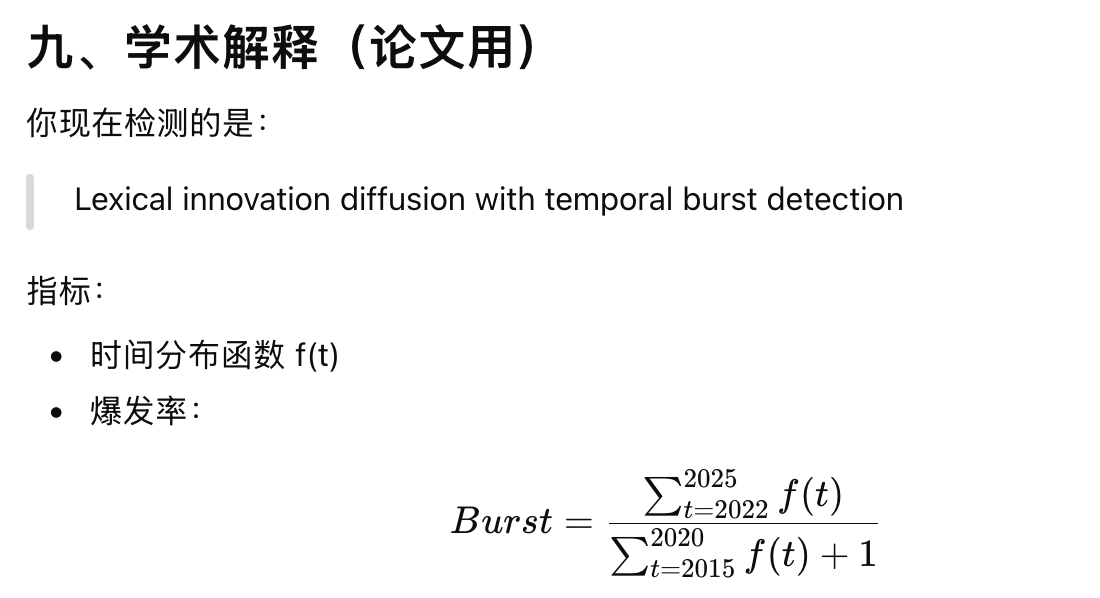

#语境抽取（给每个变体导出10条原句）

一、输入文件

假设你已有：

/content/identification/D_variant_burst.csv
/content/ch2_all_data_2015_2025_tok_thulac.csv

二、目标输出

CSV 文件：

/content/identification/E_variant_contexts.csv


字段：

| original | variant | year | sentence | url |

In [ ]:
import pandas as pd
import re
from collections import defaultdict
import numpy as np

# ========= 路径 =========
CORPUS = "/content/ch2_all_data_2015_2025_tok_thulac.csv"
VARIANT_FILE = "/content/identification/D_variant_burst.csv"
OUT_FILE = "/content/identification/E_variant_contexts.csv"

MAX_CONTEXTS = 10

# ========= 读取 =========
df = pd.read_csv(CORPUS)
df["date_parsed"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date_parsed"].dt.year
df["content"] = df["content"].fillna("").astype(str)

df_var = pd.read_csv(VARIANT_FILE)

pairs = list(zip(df_var["original"], df_var["variant"]))

print("变体数:", len(pairs))

# ========= 句子切分 =========
SENT_SPLIT = re.compile(r"[。！？!?；;]")

def split_sentences(text):
    sents = SENT_SPLIT.split(text)
    return [s.strip() for s in sents if len(s.strip()) > 5]

# ========= 抽取 =========
contexts = defaultdict(list)

for _, row in df.iterrows():
    text = row["content"]
    year = row["year"]
    url = row.get("url", "")

    if not isinstance(text, str) or len(text) < 5:
        continue

    sents = split_sentences(text)

    for orig, var in pairs:
        if len(contexts[(orig,var)]) >= MAX_CONTEXTS:
            continue

        for sent in sents:
            if var in sent:
                contexts[(orig,var)].append({
                    "original": orig,
                    "variant": var,
                    "year": year,
                    "sentence": sent,
                    "url": url
                })
                break   # 每篇文档最多取1句

# ========= 汇总 =========
rows = []
for key in contexts:
    rows.extend(contexts[key])

df_out = pd.DataFrame(rows)

# ========= 保存 =========
df_out.to_csv(OUT_FILE, index=False, encoding="utf-8-sig")

print("已保存:", OUT_FILE)
print("总语境条数:", len(df_out))
df_out.head(10)


五、增强选项（可选）
1️⃣ 优先近年

如果你想优先抽取 2022–2025 的语境：

在循环前排序：

In [ ]:
df = df.sort_values("year", ascending=False)


In [ ]:
#高质量句子过滤

#加入长度限制：

if 15 <= len(sent) <= 80:


In [ ]:
#高亮变体（可选）

sent = sent.replace(var, f"【{var}】")


#语义漂移（embedding-based polysemy detection）


In [ ]:
!pip install -q sentence-transformers scikit-learn


In [ ]:
#加载模型（中文推荐）
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")


In [ ]:
#四、基础工具函数

import pandas as pd
import numpy as np
import re
from sklearn.metrics.pairwise import cosine_distances
from sklearn.cluster import KMeans

def split_sentences(text):
    return re.split(r"[。！？!?；;]", text)

def extract_sentences_with_term(df, term):
    rows = []
    for _, r in df.iterrows():
        if term not in r["content"]:
            continue
        for sent in split_sentences(r["content"]):
            if term in sent and len(sent.strip()) > 8:
                rows.append({
                    "sentence": sent.strip(),
                    "year": r["year"]
                })
    return pd.DataFrame(rows)


In [ ]:
#核心函数：语义漂移检测（单词）

def detect_semantic_drift(term, df, min_samples=30):
    ctx = extract_sentences_with_term(df, term)

    if len(ctx) < min_samples:
        return None

    embeddings = model.encode(ctx["sentence"].tolist(), show_progress_bar=False)
    ctx["vec"] = list(embeddings)

    early = ctx[ctx["year"] <= 2018]
    late  = ctx[ctx["year"] >= 2022]

    if len(early) < 10 or len(late) < 10:
        return None

    early_centroid = np.mean(np.vstack(early["vec"]), axis=0)
    late_centroid  = np.mean(np.vstack(late["vec"]), axis=0)

    drift = cosine_distances([early_centroid], [late_centroid])[0][0]

    return {
        "term": term,
        "n_contexts": len(ctx),
        "early_centroid_years": "≤2018",
        "late_centroid_years": "≥2022",
        "semantic_drift": float(drift)
    }


设你已有：

D_variant_burst.csv


包含列：

original

variant

In [ ]:
#批量检测（对成语变体表）
df_corpus = pd.read_csv("/content/ch2_all_data_2015_2025_tok_thulac.csv")
df_corpus["date_parsed"] = pd.to_datetime(df_corpus["date"], errors="coerce")
df_corpus["year"] = df_corpus["date_parsed"].dt.year
df_corpus["content"] = df_corpus["content"].fillna("").astype(str)

df_var = pd.read_csv("/content/identification/D_variant_burst.csv")

results = []

for _, r in df_var.iterrows():
    var = r["variant"]

    out = detect_semantic_drift(var, df_corpus)

    if out:
        out["original"] = r["original"]
        results.append(out)


In [ ]:
#保存结果

df_drift = pd.DataFrame(results)
df_drift = df_drift.sort_values("semantic_drift", ascending=False)

OUT = "/content/identification/F_semantic_drift.csv"
df_drift.to_csv(OUT, index=False, encoding="utf-8-sig")

print("保存:", OUT)
df_drift.head(10)


In [ ]:
#增强：自动新义项判定标签

def label_drift(x):
    if x > 0.45: return "strong_new_sense"
    if x > 0.30: return "new_sense"
    if x > 0.15: return "weak_shift"
    return "stable"

df_drift["drift_label"] = df_drift["semantic_drift"].apply(label_drift)
